In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import os
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
import matplotlib.pyplot as plt
import math
from tqdm import tqdm


print("torch version =", torch.__version__)
print("cuda available =", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU BEIGN USED=", device)



torch version = 2.9.0+cu126
cuda available = True
GPU BEIGN USED= cuda


In [ ]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

base = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_images = []
for cls in os.listdir(os.path.join(base, "train")):
    folder = os.path.join(base, "train", cls, "images")
    if os.path.isdir(folder):
        train_images += glob.glob(os.path.join(folder, "*.JPEG"))

val_images = glob.glob(os.path.join(base, "val", "images", "*.JPEG"))

print("train =", len(train_images))
print("val   =", len(val_images))


class MyDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = transform(img)
        return img, 0


train_data = MyDataset(train_images)
val_data = MyDataset(val_images)


train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

train = 100000
val   = 10000


**Patch and masking images**

Convert image into small patches

 Example:
 
 input image shape  = (batch_size, 3, 224, 224)
 
 patch size = 16
 
 total patches = 14 x 14 = 196

In [ ]:


def make_patches(images, patch_size=16):
    batch_size, channels, height, width = images.shape
    rowwise_patches = height // patch_size
    colwise_patches = width // patch_size

    x = images.reshape(
        batch_size,
        channels,
        rowwise_patches,
        patch_size,
        colwise_patches,
        patch_size
    )

    x = x.permute(0, 2, 4, 1, 3, 5)

    x = x.reshape(
        batch_size,
        rowwise_patches * colwise_patches,
        channels * patch_size * patch_size
    )

    return x


def put_patches_back(patches, patch_size=16, image_size=224):
    batch_size = patches.shape[0]
    channels = 3
    patches_per_side = image_size // patch_size

    x = patches.reshape(
        batch_size,
        patches_per_side,
        patches_per_side,
        channels,
        patch_size,
        patch_size
    )

    x = x.permute(0, 3, 1, 4, 2, 5)

    x = x.reshape(batch_size, channels, image_size, image_size)

    return x



def random_masking(patches, mask_ratio=0.75):
    batch_size, total_patches, patch_dim = patches.shape

    num_keep = int(total_patches * (1 - mask_ratio))

    rand_values = torch.rand(batch_size, total_patches, device=patches.device)

    shuffled_ids = torch.argsort(rand_values, dim=1)

    restore_ids = torch.argsort(shuffled_ids, dim=1)

    keep_ids = shuffled_ids[:, :num_keep]

    visible_patches = torch.gather(
        patches,
        dim=1,
        index=keep_ids.unsqueeze(-1).expand(-1, -1, patch_dim)
    )

    mask = torch.ones(batch_size, total_patches, device=patches.device)
    mask[:, :num_keep] = 0
    mask = torch.gather(mask, dim=1, index=restore_ids)

    return visible_patches, mask, restore_ids

**Positional embedding helper function**

In [ ]:
import numpy as np

def get_2d_pos_embed(embed_dim, grid_size):
    assert embed_dim % 2 == 0

    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)   
    grid = np.stack(grid, axis=0)        

    pos_w = grid[0].reshape(-1)   
    pos_h = grid[1].reshape(-1)

    dim_each = embed_dim // 2

    omega_dim = dim_each // 2
    omega = np.arange(omega_dim, dtype=np.float32)
    omega = omega / omega_dim
    omega = 1.0 / (10000 ** omega)

    out_h = np.einsum('m,d->md', pos_h, omega)
    out_w = np.einsum('m,d->md', pos_w, omega)

    emb_h = np.concatenate([np.sin(out_h), np.cos(out_h)], axis=1)
    emb_w = np.concatenate([np.sin(out_w), np.cos(out_w)], axis=1)

    emb = np.concatenate([emb_h, emb_w], axis=1)

    return emb

**Encoder | Transformer Block**

In [ ]:

class TransformerBlock(nn.Module):
   def __init__(self, dim, heads, mlp_ratio=4.0, dropout=0.0):
      super().__init__()
      self.norm1 = nn.LayerNorm(dim)
      self.attn  = nn.MultiheadAttention(dim, heads,
                        dropout=dropout, batch_first=True)
      self.norm2 = nn.LayerNorm(dim)
      mlp_hidden = int(dim * mlp_ratio)
      self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout)
      )

   def forward(self, x):
      normed = self.norm1(x)
      attn_out, _ = self.attn(normed, normed, normed)
      x = x + attn_out
      x = x + self.mlp(self.norm2(x))
      return x


class MAE_Encoder(nn.Module):
   def __init__(self,
                img_size    = 224,
                patch_size  = 16,
                in_channels = 3, 
                embed_dim   = 768,
                depth       = 12, 
                num_heads   = 12):
      super().__init__()

      self.patch_size  = patch_size
      self.embed_dim   = embed_dim
      num_patches      = (img_size // patch_size) ** 2  

      patch_dim = in_channels * patch_size * patch_size  
      self.patch_embed = nn.Linear(patch_dim, embed_dim)

      self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))

      pos_embed = get_2d_pos_embed(embed_dim, img_size // patch_size)
      pos_embed = torch.from_numpy(pos_embed).float()
      pos_embed = pos_embed.unsqueeze(0)   
      self.register_buffer('pos_embed', pos_embed)

      self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads)
            for _ in range(depth)
      ])

      self.norm = nn.LayerNorm(embed_dim)

      nn.init.normal_(self.cls_token, std=0.02)

   def forward(self, x, mask_ratio=0.75):
      patches = make_patches(x, self.patch_size)  

      tokens = self.patch_embed(patches)   

      tokens = tokens + self.pos_embed

      tokens_vis, mask, ids_restore = random_masking(tokens, mask_ratio)

      cls = self.cls_token.expand(tokens_vis.shape[0], -1, -1)
      tokens_vis = torch.cat([cls, tokens_vis], dim=1)

      for blk in self.blocks:
            tokens_vis = blk(tokens_vis)

      tokens_vis = self.norm(tokens_vis)

      return tokens_vis, mask, ids_restore



**Decoder LightWeight Transformer Block**

In [ ]:

class MAE_Decoder(nn.Module):
   def __init__(self,
                num_patches    = 196,
                encoder_dim    = 768,
                decoder_dim    = 384,
                depth          = 12,
                num_heads      = 6,
                patch_size     = 16,
                in_channels    = 3):
      super().__init__()

      self.decoder_dim  = decoder_dim
      self.num_patches  = num_patches
      patch_dim         = in_channels * patch_size * patch_size   

      self.enc_to_dec = nn.Linear(encoder_dim, decoder_dim)

      self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))

      self.dec_pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, decoder_dim)
      )

      self.blocks = nn.ModuleList([
            TransformerBlock(decoder_dim, num_heads)
            for _ in range(depth)
      ])

      self.norm = nn.LayerNorm(decoder_dim)

      self.head = nn.Linear(decoder_dim, patch_dim)

      nn.init.normal_(self.mask_token, std=0.02)
      nn.init.normal_(self.dec_pos_embed, std=0.02)

   def forward(self, enc_tokens, ids_restore):
      
      x = self.enc_to_dec(enc_tokens)   

      x_no_cls = x[:, 1:, :] 
      B         = x.shape[0]
      N_vis     = x_no_cls.shape[1]   

      num_masked  = self.num_patches - N_vis   
      mask_tokens = self.mask_token.expand(B, num_masked, -1)

      combined = torch.cat([x_no_cls, mask_tokens], dim=1)   

      ids_exp  = ids_restore.unsqueeze(-1).expand(-1, -1, self.decoder_dim)
      combined = torch.gather(combined, 1, ids_exp)

      cls_dec  = x[:, :1, :]  
      combined = torch.cat([cls_dec, combined], dim=1)  

      combined = combined + self.dec_pos_embed

      for blk in self.blocks:
            combined = blk(combined)

      combined = self.norm(combined)

      combined = combined[:, 1:, :]   

      pred = self.head(combined)  
      return pred



**MAE WRAPPER**

In [ ]:

class MAE(nn.Module):
   def __init__(self):
      super().__init__()
      self.encoder = MAE_Encoder(
                  img_size   = 224,
                  patch_size = 16,
                  embed_dim  = 768,
                  depth      = 12,
                  num_heads  = 12
      )
      self.decoder = MAE_Decoder(
                  num_patches  = 196,
                  encoder_dim  = 768,
                  decoder_dim  = 384,
                  depth        = 12,
                  num_heads    = 6
      )

   def forward(self, imgs, mask_ratio=0.75):
      enc_out, mask, ids_restore = self.encoder(imgs, mask_ratio)
      pred = self.decoder(enc_out, ids_restore)
      return pred, mask


def mae_loss(pred, target_imgs, mask, patch_size=16):
      target = make_patches(target_imgs, patch_size)

      loss = (pred - target) ** 2
      loss = loss.mean(dim=-1)     

      loss = (loss * mask).sum() / mask.sum()
      return loss



**Initialize Model, Setup**

In [ ]:

model = MAE().to(device)

if torch.cuda.device_count() > 1:
   print("using", torch.cuda.device_count(), "GPUs")
   model = nn.DataParallel(model)

total_params = sum(p.numel() for p in model.parameters())
print("total parameters =", total_params)

optimizer = optim.AdamW(model.parameters(),
                        lr=1.5e-4,
                        weight_decay=0.05)

num_epochs = 20
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                   T_max=num_epochs,
                                                   eta_min=1e-6)



using 2 GPUs
total parameters = 107608704


**Training Loop**

In [10]:
dummy = torch.randn(2, 3, 224, 224).to(device)
pred, mask = model(dummy)
print(pred.shape, mask.shape)

torch.Size([2, 196, 768]) torch.Size([2, 196])


In [11]:
scaler = torch.amp.GradScaler("cuda")

loss_history = []
total_batches = num_epochs * len(train_loader)

pbar = tqdm(total=total_batches, desc="Training", leave=True)

for ep in range(num_epochs):
    model.train()
    total_loss = 0
    batch_count = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            pred, mask = model(imgs, mask_ratio=0.75)
            loss = mae_loss(pred, imgs, mask)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        batch_count += 1
        pbar.update(1)
        pbar.set_postfix(epoch=f"{ep+1}/{num_epochs}", loss=f"{total_loss/batch_count:.4f}")

    avg_loss = total_loss / batch_count
    loss_history.append(avg_loss)
    scheduler.step()

    print(f"\nepoch {ep+1}/{num_epochs}  loss = {avg_loss:.4f}  lr = {scheduler.get_last_lr()[0]:.6f}")

pbar.close()
print("training done!")

Training:   5%|▌         | 3125/62500 [21:12<6:43:48,  2.45it/s, epoch=1/20, loss=0.5096]


epoch 1/20  loss = 0.5096  lr = 0.000149


Training:  10%|█         | 6250/62500 [37:39<4:50:13,  3.23it/s, epoch=2/20, loss=0.3455]


epoch 2/20  loss = 0.3455  lr = 0.000146


Training:  15%|█▌        | 9375/62500 [54:05<4:36:54,  3.20it/s, epoch=3/20, loss=0.3077]

...


epoch 18/20  loss = 0.2158  lr = 0.000005


Training:  95%|█████████▌| 59375/62500 [5:19:12<17:35,  2.96it/s, epoch=19/20, loss=0.2151]


epoch 19/20  loss = 0.2151  lr = 0.000002


Training: 100%|██████████| 62500/62500 [5:35:57<00:00,  3.10it/s, epoch=20/20, loss=0.2144]


epoch 20/20  loss = 0.2144  lr = 0.000001
training done!


**Plotting training loss**

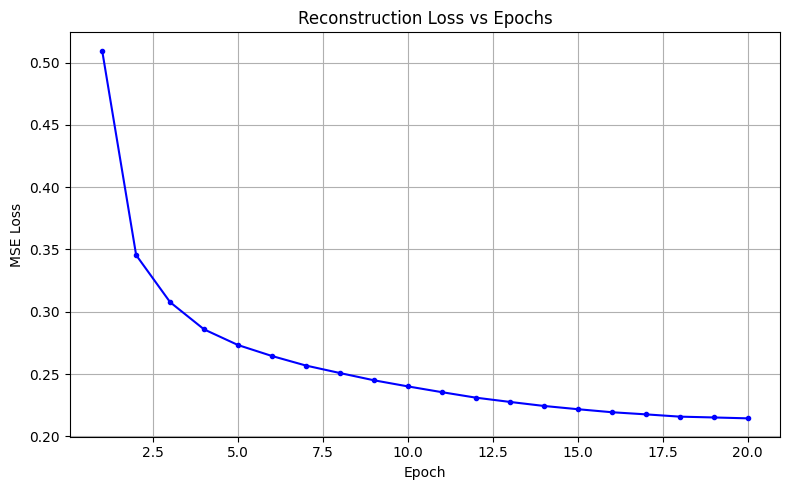

loss plot saved


In [12]:

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), loss_history, color='blue', marker='o', markersize=3)
plt.title("Reconstruction Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print("loss plot saved")



**HELPER FOR UNNORMALIZE IMAGE**

In [ ]:

def unnormalize(tensor):
      mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
      std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
      img = tensor.cpu() * std + mean
      img = img.clamp(0, 1)
      return img


def show_masked_image(original, mask, patch_size=16):
      patches  = make_patches(original.unsqueeze(0), patch_size)   
      mask_exp = mask.unsqueeze(0).unsqueeze(-1)                
      patches  = patches * (1 - mask_exp)                           
      masked_img = put_patches_back(patches, patch_size)            
      return masked_img.squeeze(0)



**Visualization**

/tmp/ipykernel_55/767604371.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8956583..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.64].


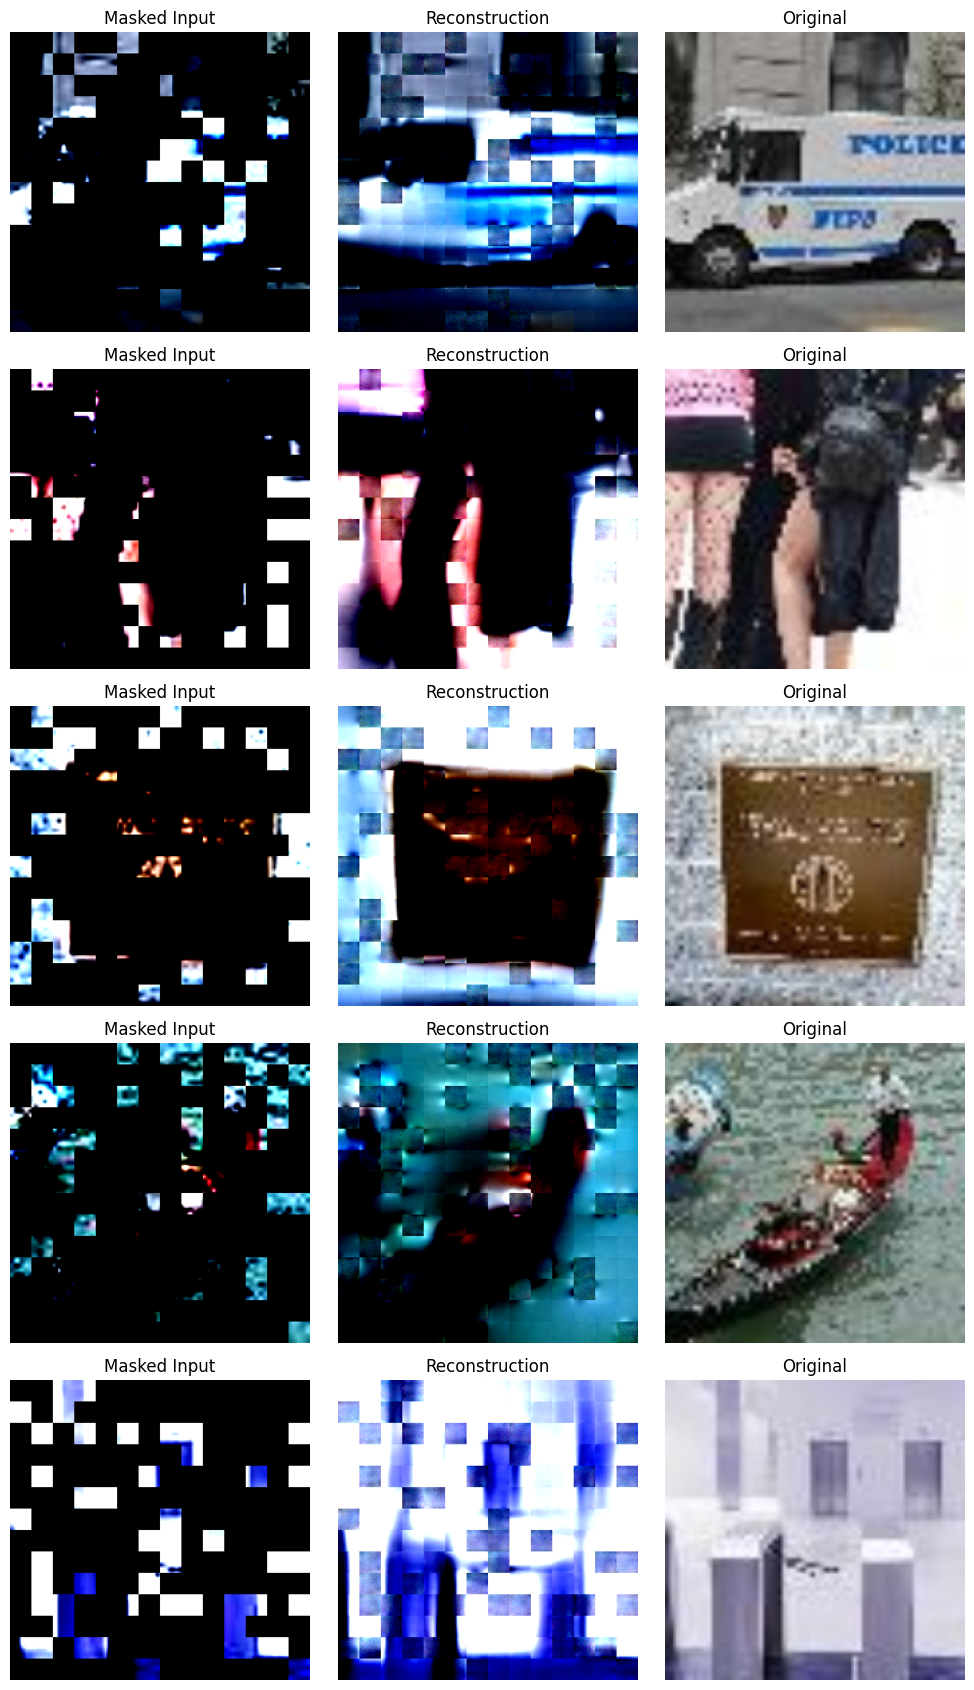

visualization saved


In [ ]:

model.eval()

sample_imgs, _ = next(iter(val_loader))
sample_imgs = sample_imgs.to(device)

with torch.no_grad():
      with torch.cuda.amp.autocast():
            pred, mask = model(sample_imgs[:5], mask_ratio=0.75)

pred_imgs = put_patches_back(pred[:5].float(), patch_size=16).cpu()

fig, axes = plt.subplots(5, 3, figsize=(10, 17))

for i in range(5):
      orig      = unnormalize(sample_imgs[i].cpu())
      masked    = show_masked_image(sample_imgs[i].cpu(), mask[i].cpu())
      recon     = pred_imgs[i]
      recon_un  = recon.clamp(0, 1)   

      axes[i][0].imshow(masked.permute(1,2,0).numpy())
      axes[i][0].set_title("Masked Input")
      axes[i][0].axis('off')

      axes[i][1].imshow(recon_un.permute(1,2,0).numpy())
      axes[i][1].set_title("Reconstruction")
      axes[i][1].axis('off')

      axes[i][2].imshow(orig.permute(1,2,0).numpy())
      axes[i][2].set_title("Original")
      axes[i][2].axis('off')

plt.tight_layout()
plt.savefig("reconstructions.png", dpi=150)
plt.show()
print("visualization saved")


**PSNR and SSIM scores**

In [ ]:

psnr_scores = []
ssim_scores = []

model.eval()
with torch.no_grad():
   for imgs, _ in val_loader:
      imgs = imgs.to(device)
      with torch.cuda.amp.autocast():
            pred, mask = model(imgs, mask_ratio=0.75)

      pred_img = put_patches_back(pred.float(), patch_size=16).cpu()
      orig_img = imgs.cpu()

      for j in range(pred_img.shape[0]):
            orig_np = unnormalize(orig_img[j]).permute(1,2,0).numpy()
            recon_np = pred_img[j].clamp(0,1).permute(1,2,0).numpy()

            p = psnr_fn(orig_np, recon_np, data_range=1.0)
            s = ssim_fn(orig_np, recon_np, channel_axis=2, data_range=1.0)

            psnr_scores.append(p)
            ssim_scores.append(s)

      if len(psnr_scores) >= 200:
            break

print(f"average PSNR = {np.mean(psnr_scores):.2f} dB")
print(f"average SSIM = {np.mean(ssim_scores):.4f}")


/tmp/ipykernel_55/3068431564.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


average PSNR = 11.01 dB
average SSIM = 0.1847


In [ ]:

state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
torch.save(state, "model_mae.pth")
print("model saved to model_mae.pth")



model saved to model_mae.pth
